In [11]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [12]:

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [13]:
data_dir

'./datasets/flower_photos'

In [21]:
import pathlib
data_dir = pathlib.Path(data_dir) / "flower_photos"
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [15]:
list(data_dir.glob('*/*.jpg'))[:5]

[]

In [16]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

0


In [17]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[]

In [18]:
if len(roses) > 1:
    PIL.Image.open(str(roses[1]))
else:
    print("Not enough rose images found to access index 1. The 'roses' list is currently empty or has only one element.")
    print("Please check the dataset download and extraction, and ensure image files are present in the 'roses' directory within:", data_dir)

Not enough rose images found to access index 1. The 'roses' list is currently empty or has only one element.
Please check the dataset download and extraction, and ensure image files are present in the 'roses' directory within: datasets/flower_photos


In [19]:
!ls -R datasets/flower_photos | head -n 20

datasets/flower_photos:
flower_photos

datasets/flower_photos/flower_photos:
daisy
dandelion
LICENSE.txt
roses
sunflowers
tulips

datasets/flower_photos/flower_photos/daisy:
100080576_f52e8ee070_n.jpg
10140303196_b88d3d6cec.jpg
10172379554_b296050f82_n.jpg
10172567486_2748826a8b.jpg
10172636503_21bededa75_n.jpg
102841525_bd6628ae3c.jpg
1031799732_e7f4008c03.jpg
10391248763_1d16681106_n.jpg


In [22]:
tulips = list(data_dir.glob('tulips/*'))
if len(tulips) > 0:
    PIL.Image.open(str(tulips[0]))
else:
    print(f'No images found in {data_dir}/tulips. Please ensure the directory path is correct.')

In [23]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [24]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [25]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/5050969148_a0090f762a.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/8032328803_30afac8b07_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2627513944_b1361e60ec_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2888138918_402096c7fb.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2392457180_f02dab5c65.jpg')]

In [26]:
str(flowers_images_dict['roses'][0])

'datasets/flower_photos/flower_photos/roses/5050969148_a0090f762a.jpg'

In [27]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [28]:
img.shape

(333, 500, 3)

In [29]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [30]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [31]:
X = np.array(X)
y = np.array(y)

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

**Preprocessing: scale images**

In [33]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [34]:

num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.4088 - loss: 1.3644
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6065 - loss: 1.0047
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7028 - loss: 0.7930
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7849 - loss: 0.5886
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8815 - loss: 0.3536
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 142s 999ms/step - accuracy: 0.9364 - loss: 0.1976
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9757 - loss: 0.0904
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9891 - loss: 0.0402
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9840 - loss: 0.0626
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9942 - loss: 0.0292
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9902 - loss: 0.0443
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0

In [35]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 335ms/step - accuracy: 0.6460 - loss: 2.1308


[2.130798816680908, 0.6459695100784302]

**Here we see that while train accuracy is very high (99%), the test accuracy is significantly low (66.99%) indicating overfitting. Let's make some predictions before we use data augmentation to address overfitting**

In [36]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step


array([[ 13.63427   ,   8.232211  ,  -6.107182  ,  -4.4152513 ,
          4.8279605 ],
       [  8.111858  ,  -4.7597766 ,  -6.921491  ,  -0.04156203,
          9.867397  ],
       [  1.357471  ,  -8.998364  ,   5.1195054 ,  17.670906  ,
          4.262258  ],
       ...,
       [ -1.588781  ,  -3.4343557 ,   0.85616904,  15.805846  ,
         -0.41141784],
       [  7.3602095 ,   1.0997424 ,  -8.41582   ,  -2.0742712 ,
          9.859138  ],
       [  7.506047  ,   6.847901  , -12.280587  ,   8.016782  ,
          3.6012926 ]], dtype=float32)

In [37]:
score = tf.nn.softmax(predictions[0])

In [38]:
np.argmax(score)

np.int64(0)

In [39]:
y_test[0]

np.int64(1)

**Improve Test Accuracy Using Data Augmentation**

In [41]:
img_height, img_width = 180, 180

data_augmentation = keras.Sequential(
  [
    layers.Input(shape=(img_height, img_width, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


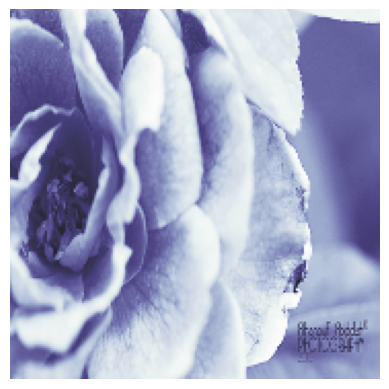

In [42]:
plt.axis('off')
plt.imshow(X[0])

**Newly generated training sample using data augmentation**

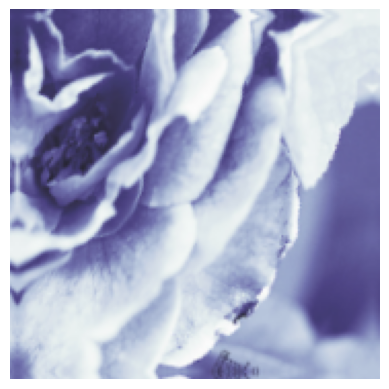

In [43]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

**Train the model using data augmentation and a drop out layer**

In [44]:

num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.3129 - loss: 1.5108
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.5385 - loss: 1.1314
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.5923 - loss: 1.0217
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6319 - loss: 0.9341
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6559 - loss: 0.8818
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6759 - loss: 0.8214
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.7042 - loss: 0.7874
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7115 - loss: 0.7507
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.7315 - loss: 0.6966
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7431 - loss: 0.6726
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7456 - loss: 0.6476
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy:

In [45]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 495ms/step - accuracy: 0.7277 - loss: 0.8844


[0.8844133019447327, 0.727668821811676]